In [1]:
import seaborn as sns
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import math
from itertools import product
from collections import defaultdict, Counter
from scipy.special import logsumexp
from matplotlib.colors import LinearSegmentedColormap

### Transmission Mode

In [2]:
group_rounds = [0, 10, 20]
turnover_rounds = [0, 10, 20]
pop_sizes = [25]
n_runs = 50
modes = ["Sample", "MAP"] 
replaced = [False, True]

In [3]:
missing_params = []

for mode in modes:
    for replace in replaced:
        list_df = []
        for group_round in group_rounds:
            for turnover_round in turnover_rounds:
                for pop_size in pop_sizes:
                    if (group_round != 0 or turnover_round != 0):
                        name = f"h{group_round}_v{turnover_round}_p{pop_size}"
                        results_dir = f"Transmission_mode/results_snellius/{mode}/{replace}/{name}"
                        for run in range(n_runs):
                            filepath = f"{results_dir}/run{run}.csv"
                            if not os.path.exists(filepath):
                                missing_params.append(filepath)
                                continue
                            df = pd.read_csv(filepath)
                            df["condition"] = f"{turnover_round} vertical transmission, {group_round} horizontal transmission"
                            list_df.append(df)

        save_dir = f"Transmission_mode/plots/{mode}/{replace}"
        os.makedirs(save_dir, exist_ok=True)
        if list_df:
            big_df = pd.concat(list_df)
            big_df.to_csv(f"{save_dir}/{mode}.csv")

if missing_params:
    with open("missing_files.txt", "w") as f:
        f.write("\n".join(missing_params))
    print(f"Warning: {len(missing_params)} missing file(s) logged to missing_files.txt")

In [4]:

def fast_plot_exp1(csv_path_replaced, csv_path_not_replaced, title, save_path):
    # Load both datasets
    df_replaced = pd.read_csv(f"{csv_path_replaced}.csv")
    df_not_replaced = pd.read_csv(f"{csv_path_not_replaced}.csv")

    # Define consistent color palette and order
    palette = [
        "#F0C77B", "#E69F00",  # Golden-orange (group 1)
        "#B4C9F0", "#56B4E9", "#0072B2",  # Blue-purple (group 2)
        "#B7E3CD", "#73D6B1", "#009E73"   # Teal-green (group 3)
    ]

    hue_order = [
        "0 vertical transmission, 10 horizontal transmission",
        "0 vertical transmission, 20 horizontal transmission", 
        "10 vertical transmission, 0 horizontal transmission", 
        "10 vertical transmission, 10 horizontal transmission",
        "10 vertical transmission, 20 horizontal transmission", 
        "20 vertical transmission, 0 horizontal transmission",
        "20 vertical transmission, 10 horizontal transmission", 
        "20 vertical transmission, 20 horizontal transmission"
    ]

    # Mapping conditions to colors
    condition_to_color = dict(zip(hue_order, palette))

    # calculate CI and return summary
    def compute_summary(df):
        grouped = df.groupby(['condition', 'generation'])['compositional']
        mean = grouped.mean()
        sem = grouped.sem()
        ci_hi = mean + 1.96 * sem
        ci_lo = mean - 1.96 * sem
        return pd.DataFrame({
            'mean': mean,
            'ci_lo': ci_lo,
            'ci_hi': ci_hi
        }).reset_index()

    summary_replaced = compute_summary(df_replaced)
    summary_not_replaced = compute_summary(df_not_replaced)

    # Setup subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    def plot_summary(ax, summary, subtitle, show_ylabel=True):
        for condition in hue_order:
            cond_data = summary[summary['condition'] == condition]
            if cond_data.empty:
                continue
            ax.plot(cond_data['generation'], cond_data['mean'], label=condition, color=condition_to_color[condition], 
                    )
            ax.fill_between(cond_data['generation'], cond_data['ci_lo'], cond_data['ci_hi'],
                            alpha=0.05, color=condition_to_color[condition], rasterized=True)

        print(f"\nFinal compositionality levels for: {subtitle}")
        for condition in hue_order:
            cond_data = summary[summary['condition'] == condition]
            if cond_data.empty:
                continue
            final_gen = cond_data['generation'].max()
            final_row = cond_data[cond_data['generation'] == final_gen]
            if not final_row.empty:
                mean_val = final_row['mean'].values[0]
                ci_lo_val = final_row['ci_lo'].values[0]
                ci_hi_val = final_row['ci_hi'].values[0]
                print(f"  {condition}: {mean_val:.3f} (95% CI: {ci_lo_val:.3f} – {ci_hi_val:.3f})")

        ax.set_title(subtitle)
        ax.set_xlabel("Iteration")
        if show_ylabel:
            ax.set_ylabel("Proportion compositional")
        ax.grid(True)
        ax.tick_params(labelleft=True)
        if not cond_data.empty:
            ax.set_xlim(cond_data['generation'].min(), cond_data['generation'].max())


    # Plot both panels
    plot_summary(ax1, summary_replaced, "All agents replaced each iteration", show_ylabel=True)
    plot_summary(ax2, summary_not_replaced, "One agent replaced each iteration", show_ylabel=False)

        # Group the hue_order into color groups
    group1 = hue_order[0:2]  # Golden-orange
    group2 = hue_order[2:5]  # Blue-purple
    group3 = hue_order[5:8]  # Teal-green
    

    # Dummy line for spacing
    def dummy_line():
        return Line2D([], [], linestyle='none')  # Invisible, valid handle

    # Helper to generate legend handles/labels for a group
    def get_legend_items(group, target_len):
        handles = [Line2D([0], [0], color=condition_to_color[cond], lw=3) for cond in group]
        labels = group
        # Pad to match longest column
        while len(handles) < target_len:
            handles.append(dummy_line())
            labels.append("")
        return handles, labels

    # Compute max column height
    max_len = max(len(group1), len(group2), len(group3))

    # Get padded handles and labels
    handles1, labels1 = get_legend_items(group1, max_len)
    handles2, labels2 = get_legend_items(group2, max_len)
    handles3, labels3 = get_legend_items(group3, max_len)

    # Combine for legend
    flat_handles = handles1 + handles2 + handles3
    flat_labels = labels1 + labels2 + labels3

    # Add custom legend
    fig.legend(
        handles=flat_handles,
        labels=flat_labels,
        title="Condition",
        loc='lower center',
        ncol=3,  # One column per group
        fontsize='small',
        title_fontsize='medium',
        frameon=True,                      
        framealpha=1.0,                    
        edgecolor='grey', 
        columnspacing=1.5,
        handletextpad=0.5,
        bbox_to_anchor=(0.5, -0.18)
    )

    fig.suptitle(title, fontsize=20)
    fig.tight_layout(rect=[0, 0.01, 1, 0.93])  # Adjust for legend space
    plt.savefig(f"{save_path}_1.pdf", bbox_inches='tight', pad_inches=0.05)
    plt.show()
    plt.clf()



Final compositionality levels for: All agents replaced each iteration
  0 vertical transmission, 10 horizontal transmission: 0.180 (95% CI: 0.072 – 0.288)
  0 vertical transmission, 20 horizontal transmission: 0.180 (95% CI: 0.072 – 0.288)
  10 vertical transmission, 0 horizontal transmission: 0.014 (95% CI: 0.008 – 0.020)
  10 vertical transmission, 10 horizontal transmission: 0.006 (95% CI: 0.003 – 0.009)
  10 vertical transmission, 20 horizontal transmission: 0.006 (95% CI: 0.003 – 0.009)
  20 vertical transmission, 0 horizontal transmission: 0.728 (95% CI: 0.709 – 0.748)
  20 vertical transmission, 10 horizontal transmission: 0.755 (95% CI: 0.729 – 0.781)
  20 vertical transmission, 20 horizontal transmission: 0.764 (95% CI: 0.741 – 0.788)

Final compositionality levels for: One agent replaced each iteration
  0 vertical transmission, 10 horizontal transmission: 0.180 (95% CI: 0.072 – 0.288)
  0 vertical transmission, 20 horizontal transmission: 0.180 (95% CI: 0.072 – 0.288)
  10 

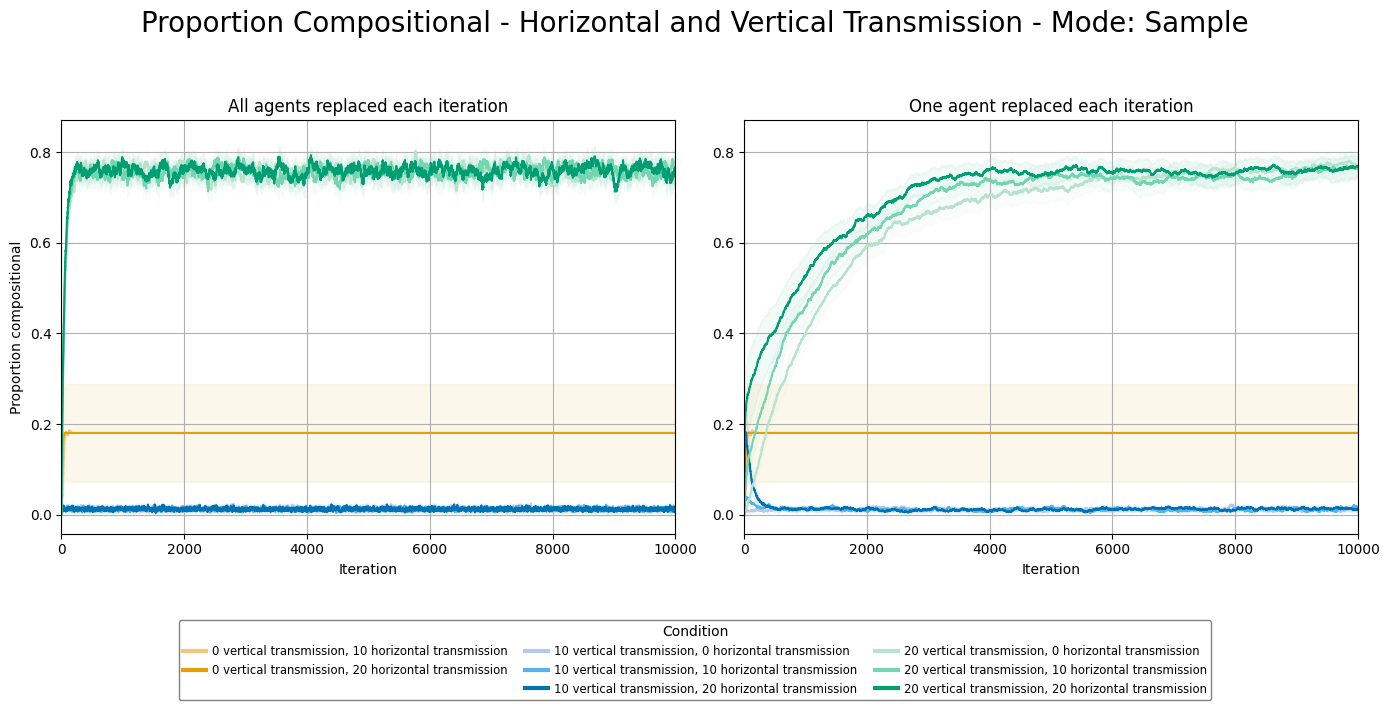


Final compositionality levels for: All agents replaced each iteration
  0 vertical transmission, 10 horizontal transmission: 0.200 (95% CI: 0.088 – 0.312)
  0 vertical transmission, 20 horizontal transmission: 0.140 (95% CI: 0.043 – 0.237)
  10 vertical transmission, 0 horizontal transmission: 0.021 (95% CI: 0.015 – 0.027)
  10 vertical transmission, 10 horizontal transmission: 0.029 (95% CI: 0.020 – 0.037)
  10 vertical transmission, 20 horizontal transmission: 0.029 (95% CI: 0.020 – 0.039)
  20 vertical transmission, 0 horizontal transmission: 0.774 (95% CI: 0.750 – 0.798)
  20 vertical transmission, 10 horizontal transmission: 0.765 (95% CI: 0.741 – 0.788)
  20 vertical transmission, 20 horizontal transmission: 0.761 (95% CI: 0.735 – 0.786)

Final compositionality levels for: One agent replaced each iteration
  0 vertical transmission, 10 horizontal transmission: 0.200 (95% CI: 0.088 – 0.312)
  0 vertical transmission, 20 horizontal transmission: 0.140 (95% CI: 0.043 – 0.237)
  10 

<Figure size 640x480 with 0 Axes>

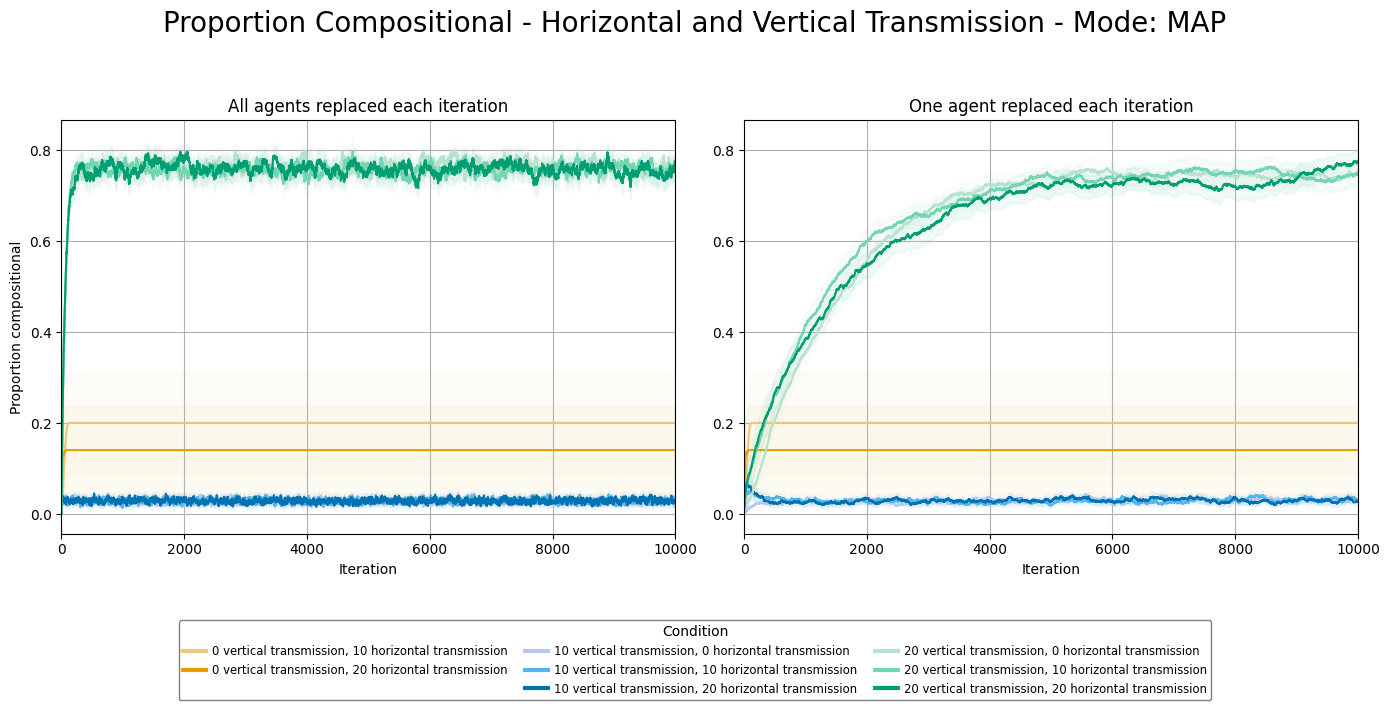

<Figure size 640x480 with 0 Axes>

In [5]:
for mode in modes:
    csv_path1 = f"Transmission_mode/plots/{mode}/True/{mode}"
    csv_path2 = f"Transmission_mode/plots/{mode}/False/{mode}"
        
    title = f"Proportion Compositional - Horizontal and Vertical Transmission - Mode: {mode}"
    fast_plot_exp1(csv_path1, csv_path2, title, save_path=f"Transmission_mode/plots/{mode}")


In [6]:
def plot_each_language_type_ax(ax, results, title):
    grouped = results.groupby("generation")[["degenerate", "holistic", "other", "compositional"]]
    
    # Compute mean, std, and n
    grouped_mean = grouped.mean()
    grouped_sem = grouped.sem()
    
    # Compute standard error and 95% CI using t-distribution
    ci95 = 1.96 * grouped_sem  

    colors = {
        "degenerate": "#d62728",    # red
        "holistic": "#1f77b4",      # blue
        "other": "#9467bd",         # purple
        "compositional": "#2ca02c"  # green
    }

    for col in grouped_mean.columns:
        mean = grouped_mean[col]
        ci = ci95[col]

        ax.plot(grouped_mean.index, mean, label=col, color=colors[col])
        ax.fill_between(grouped_mean.index, mean - ci, mean + ci, alpha=0.2, color=colors[col], rasterized=True)

    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="both", which="both", labelsize=9)

def plot_grid(big_df, save_to, mode, replace, alpha):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))  # no sharex/sharey

    verticals = [20, 10, 0]      # top → bottom
    horizontals = [0, 10, 20]    # left → right

    for i, v in enumerate(verticals):
        for j, h in enumerate(horizontals):
            ax = axes[i, j]

            # skip bottom-left corner (v=0, h=0)
            if v == 0 and h == 0:
                ax.axis("off")

                # place legend here in 2x2 grid
                handles, labels = axes[0,1].get_legend_handles_labels()
                ax.legend(
                    handles, labels,
                    loc="center",
                    ncol=2,        # 2x2 grid
                    title="Type",
                    fontsize=10,
                    frameon=True
                )
                continue

            subset = big_df[
                (big_df["condition"] == f"{v} vertical transmission, {h} horizontal transmission")
            ]

            if not subset.empty:
                plot_each_language_type_ax(ax, subset, f"v={v}, h={h}")
            else:
                ax.axis("off")

            # axis labels on all subplots
            if v == 0:
                ax.set_xlabel("Iteration", fontsize=9)
            if h == 0 or (v==0 and h==10):
                ax.set_ylabel("Avg. Proportion", fontsize=9)

            # Limit x-axis to 0-10000
            ax.set_xlim(0, 10000)

    # Axis annotations
    fig.text(0.5, 0.01, "Horizontal Transmission →", ha="center", fontsize=13)
    fig.text(0.01, 0.5, "Vertical Transmission →", va="center", rotation="vertical", fontsize=13)

    # Title at the top
    replace_str = "Entire Population" if replace else "1 Agent per iteration"
    if alpha == 0:
        fig.suptitle(f"Proportion per language type - Mode: {mode} - Replacement: {replace_str}", fontsize=14, y=0.95)
    else:
        fig.suptitle(f"Proportion per language type - Alpha: {alpha} - Mode: {mode} - Replacement: {replace_str}", fontsize=14, y=0.95)


    plt.tight_layout(rect=[0.05, 0.05, 1, 0.93])  # adjust to keep title
    plt.savefig(f"{save_to}_{mode}.pdf", bbox_inches="tight", pad_inches=0.05)
    plt.show()


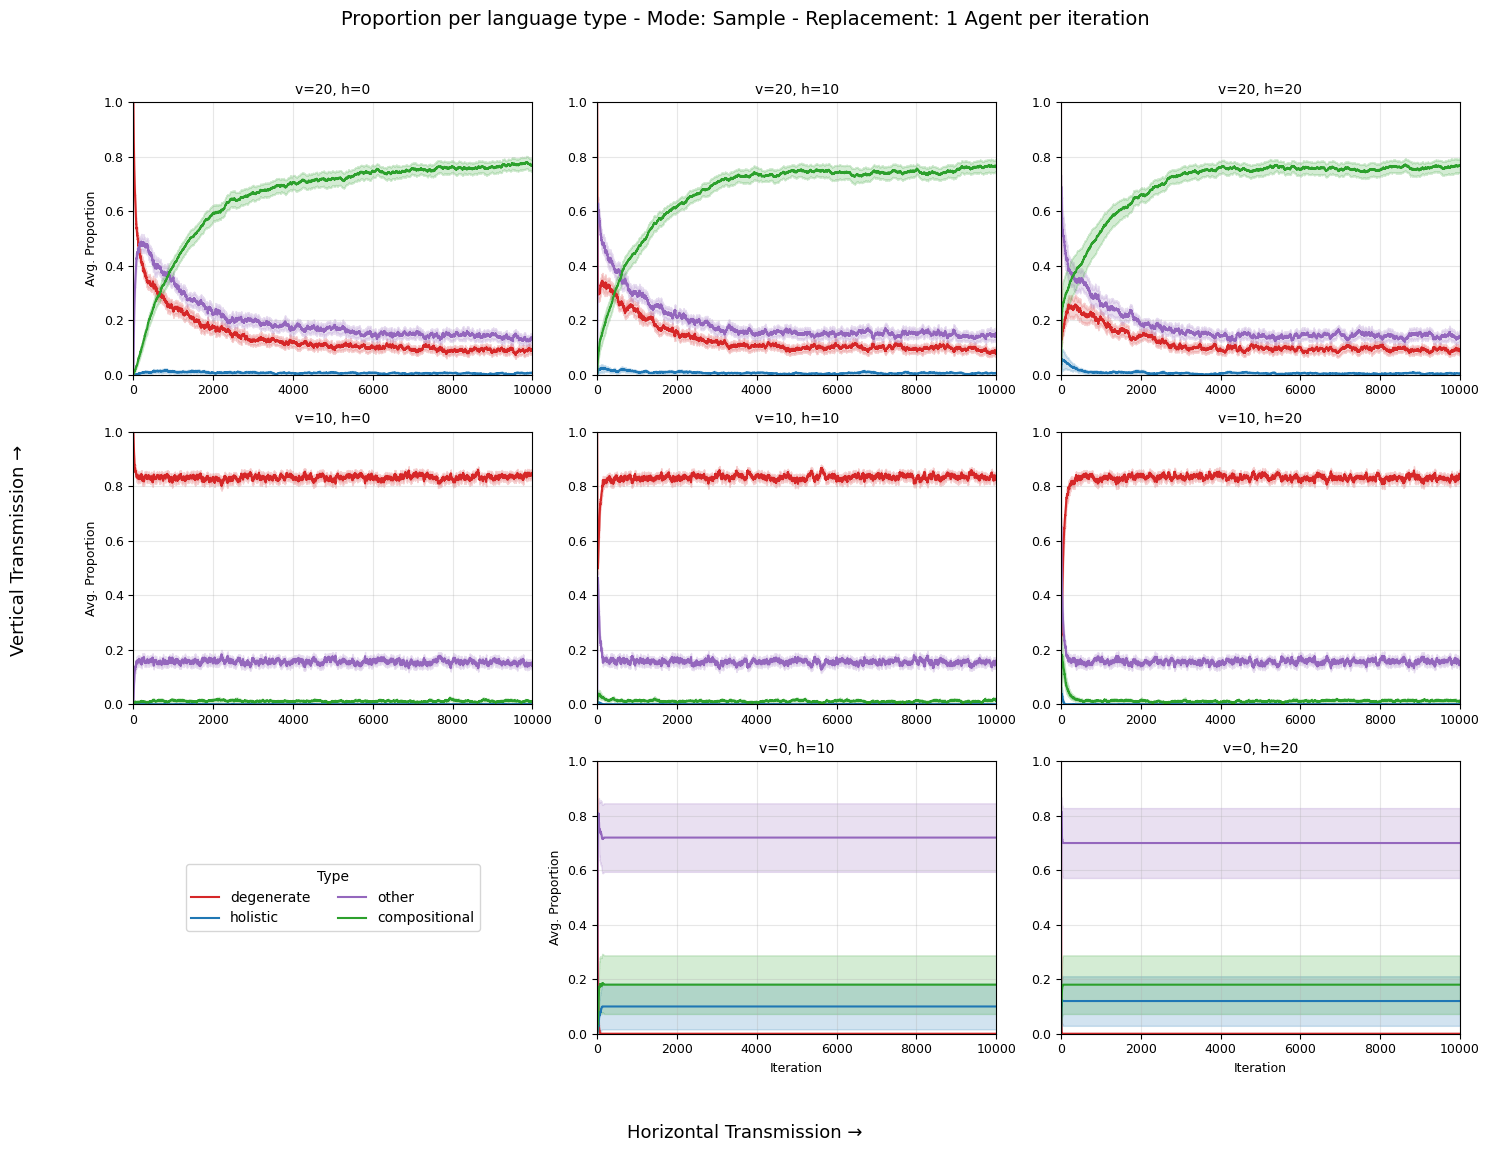

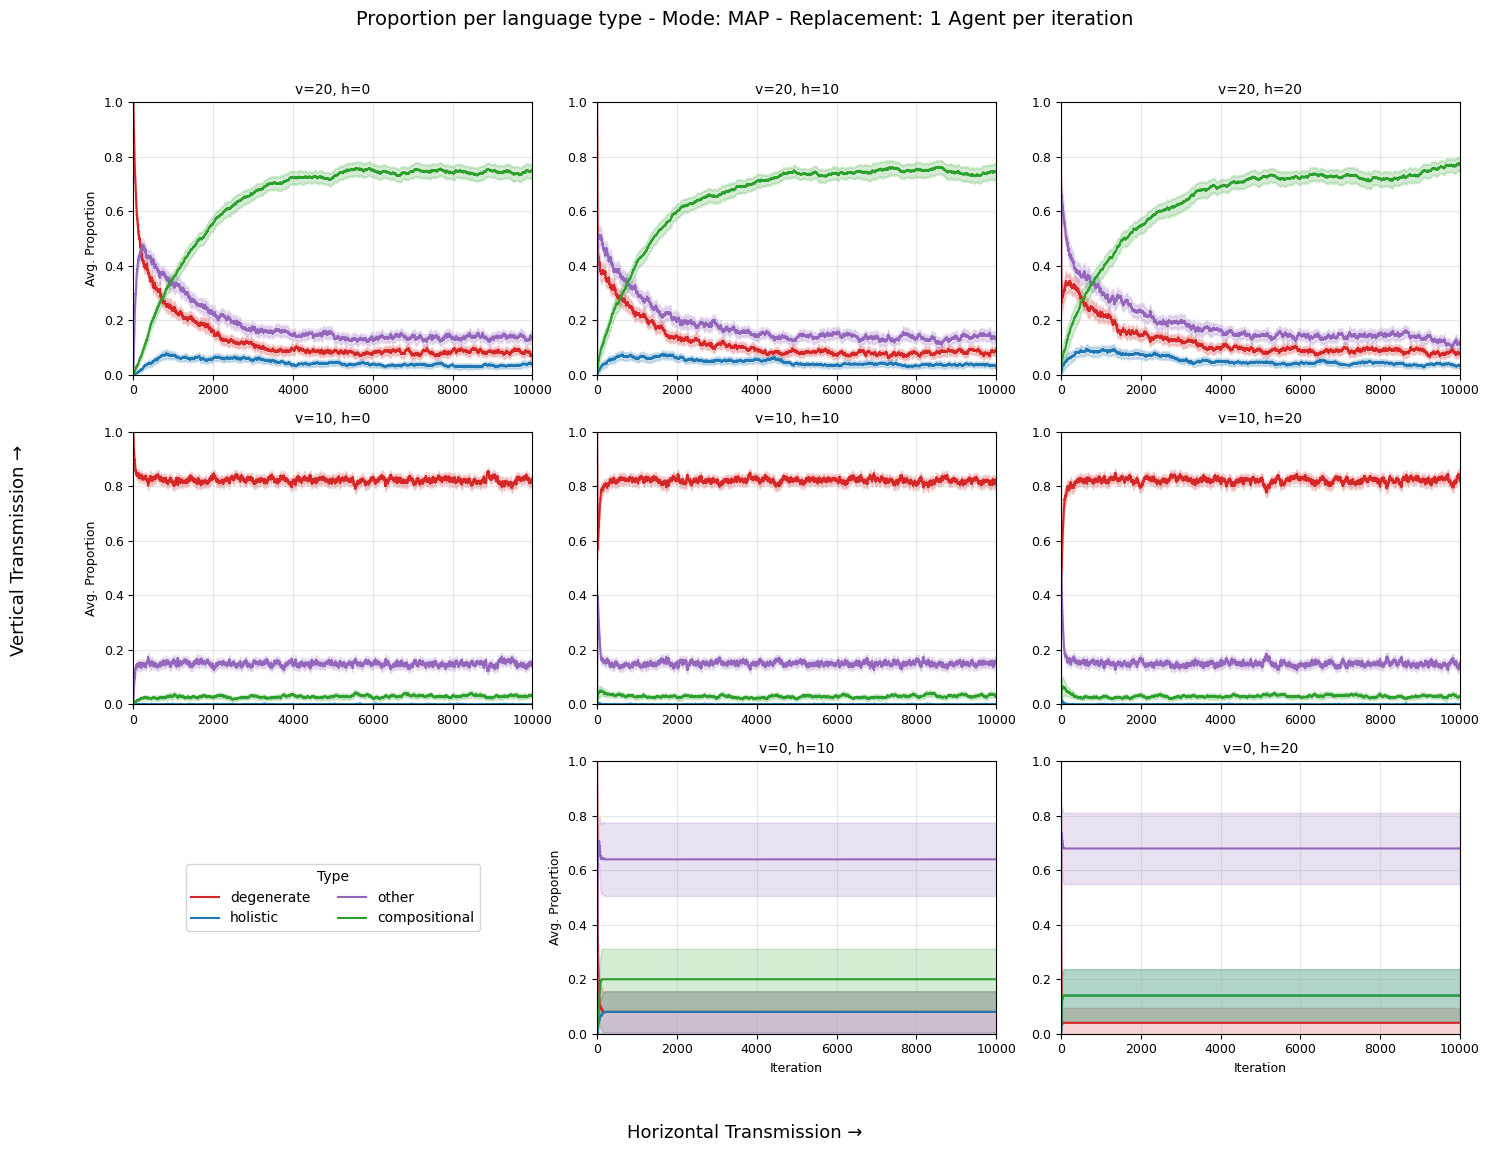

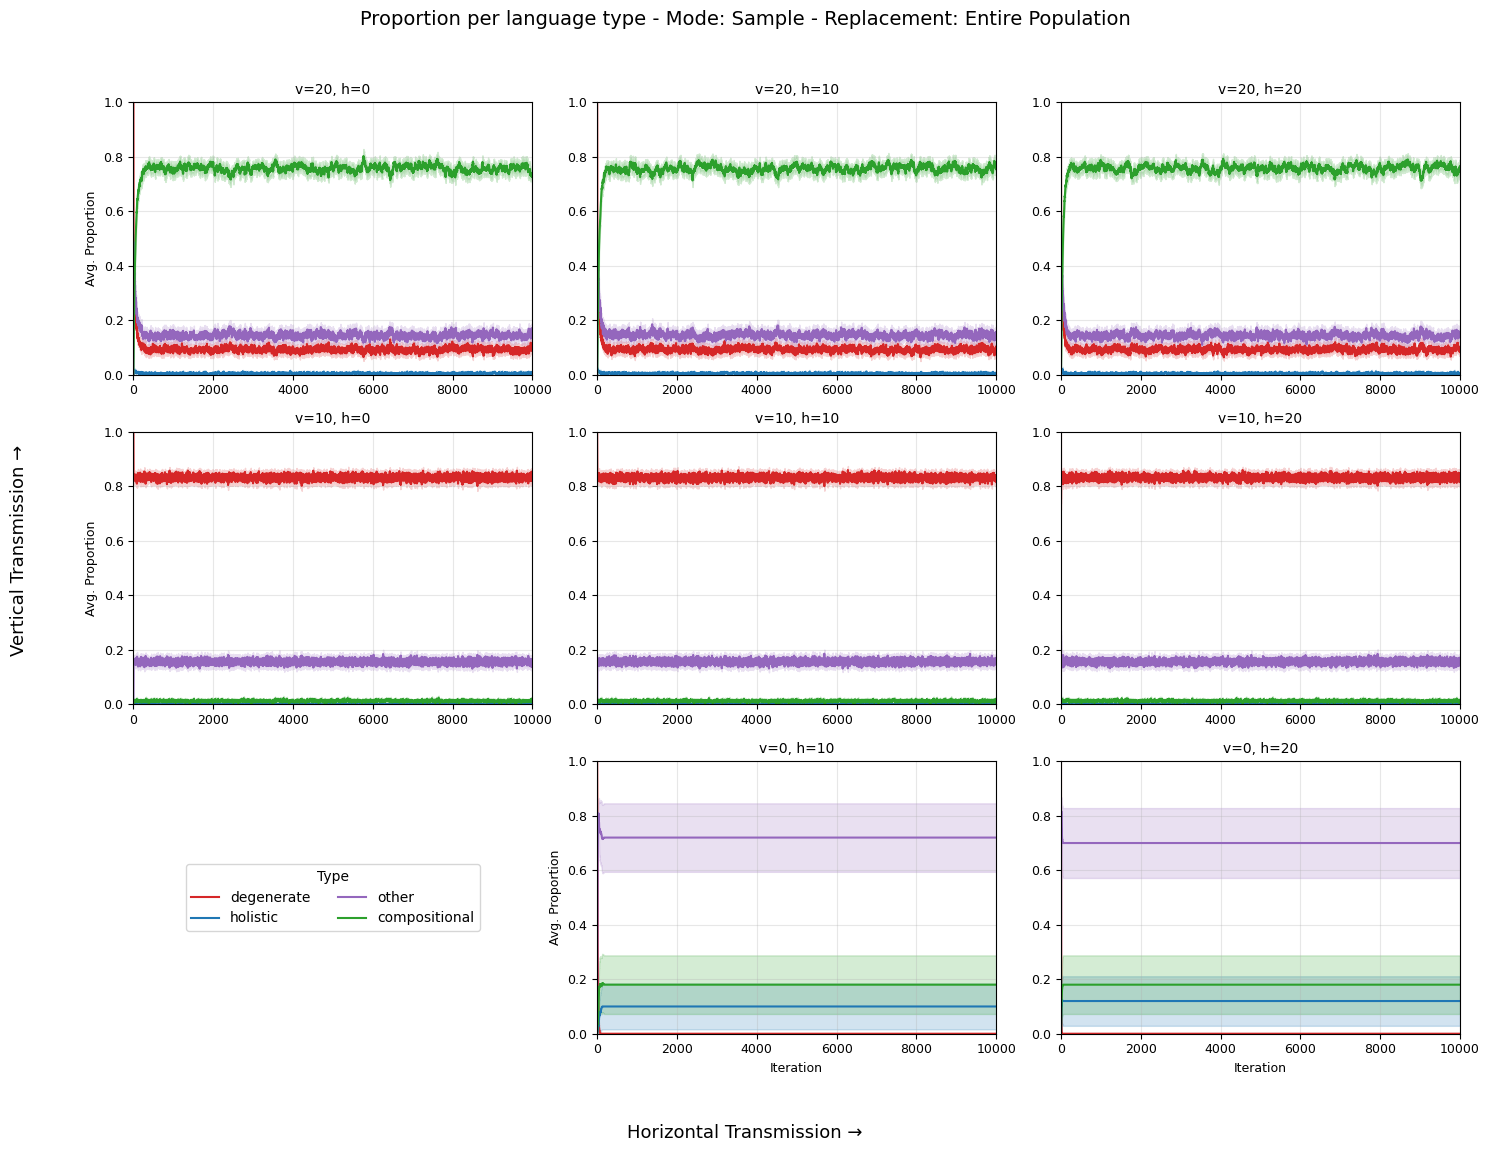

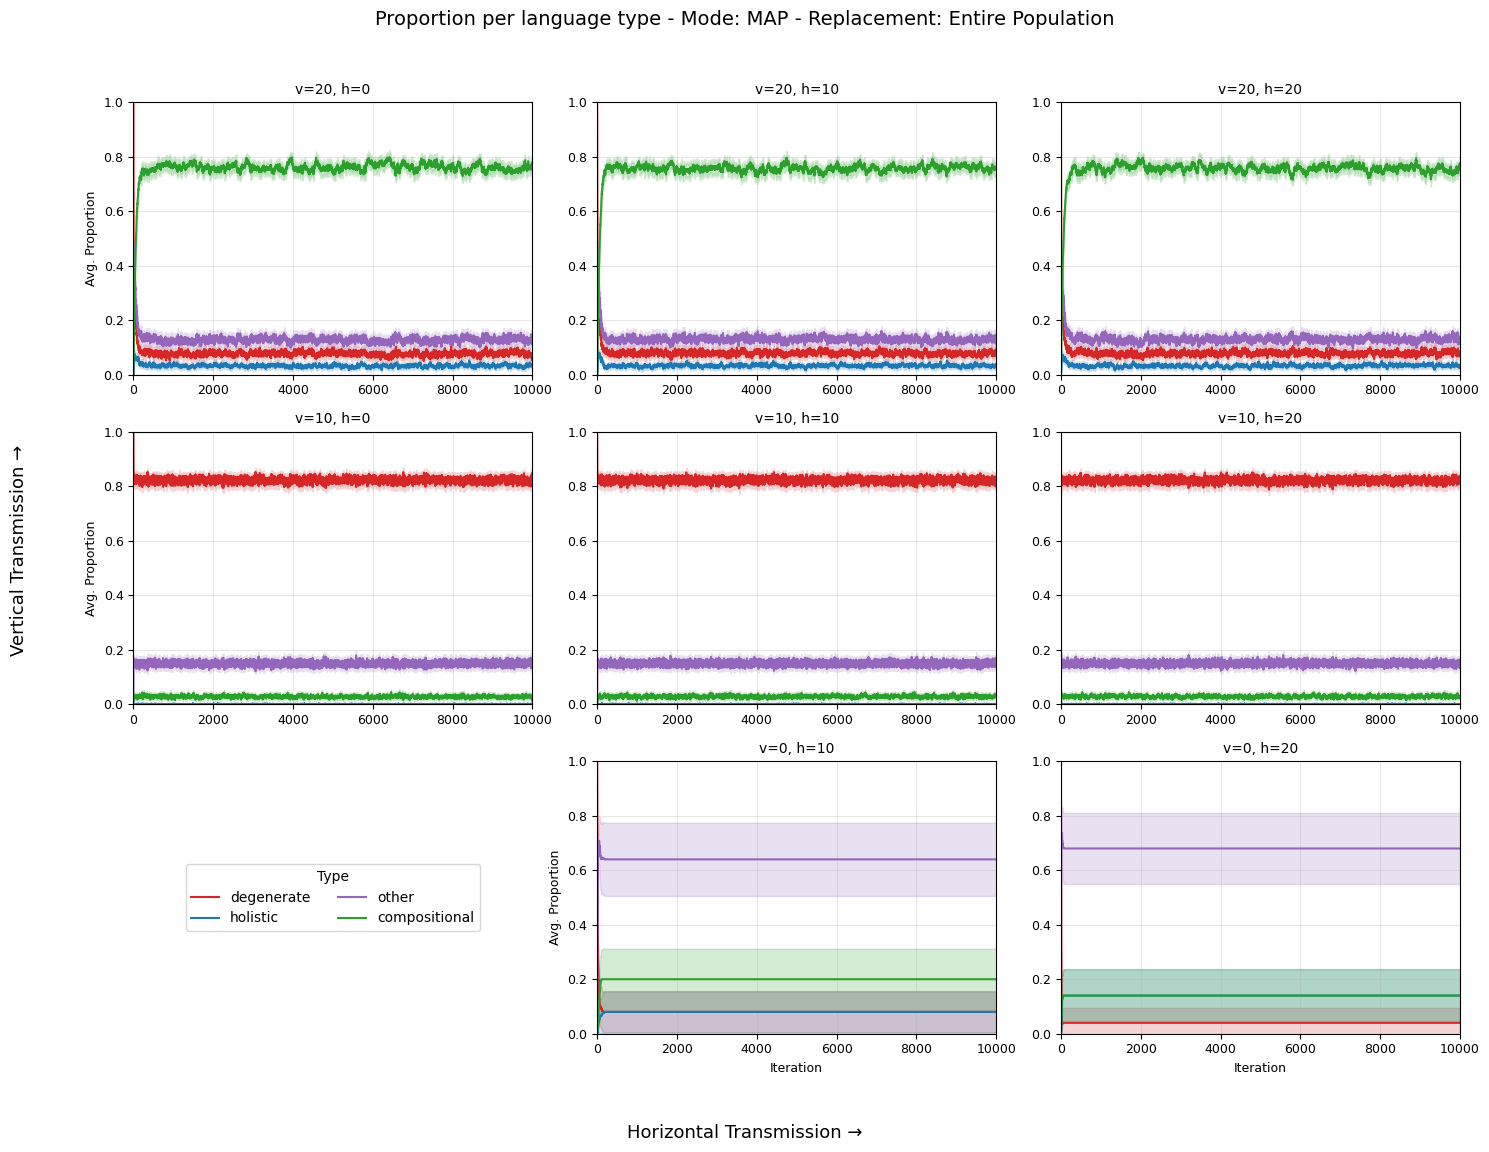

In [7]:
for replace in replaced:
    for mode in modes:
        csv_path = f"Transmission_mode/plots/{mode}/{replace}"
        df = pd.read_csv(f"{csv_path}/{mode}.csv")
        save_path = csv_path
        plot_grid(df, save_path, mode, replace, 0)

### Population Size

In [8]:
group_rounds = [20]
turnover_rounds = [20]
pop_sizes = [2, 10, 25, 50, 100, 200]
n_runs = 50
modes = ["Sample", "MAP"] 
replaced = [False, True]

In [9]:
for mode in modes:
    for replace in replaced:
        list_df = []
        for group_round in group_rounds:
            for turnover_round in turnover_rounds:
                for pop_size in pop_sizes:
                    path = f"Population_size/results_snellius/{mode}/{replace}/h{group_round}_v{turnover_round}_p{pop_size}"
                    for run in range(n_runs):
                        df = pd.read_csv(f"{path}/run{run}.csv")
                        list_df.append(df)
        
        save_dir = f"Population_size/plots/{mode}/{turnover_round}/{replace}"
        os.makedirs(save_dir, exist_ok=True)  
        big_df = pd.concat(list_df)
        big_df.to_csv(f"{save_dir}/{mode}.csv")

In [ ]:
def fast_plot_ex2(csv_path1, csv_path2, title, save_path):
    # Load both CSVs
    df1 = pd.read_csv(f"{csv_path1}.csv")
    df2 = pd.read_csv(f"{csv_path2}.csv")

    def compute_summary(df):
        grouped = df.groupby(['popsize', 'generation'])['compositional']
        mean = grouped.mean()
        sem = grouped.sem()
        ci_hi = mean + 1.96 * sem
        ci_lo = mean - 1.96 * sem
        return pd.DataFrame({'mean': mean, 'ci_lo': ci_lo, 'ci_hi': ci_hi}).reset_index()

    summary1 = compute_summary(df1)
    summary2 = compute_summary(df2)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    
    def plot_summary(ax, summary, title, labelyaxis):
        pops = sorted(summary['popsize'].unique())
        colors = plt.cm.viridis(np.linspace(0, 1, len(pops)))

        markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'x', '+']

        
        for i, pop in enumerate(summary['popsize'].unique()):
            pop_data = summary[summary['popsize'] == pop]
            ax.plot(pop_data['generation'], pop_data['mean'], color=colors[i], label=f'{pop}', marker=markers[i], markersize=7, markevery=750)
            ax.fill_between(pop_data['generation'], pop_data['ci_lo'], pop_data['ci_hi'], color=colors[i], alpha=0.05, rasterized=True)

            if pop_data.empty:
                continue
            final_gen = pop_data['generation'].max()
            final_row = pop_data[pop_data['generation'] == final_gen]
            if not final_row.empty:
                mean_val = final_row['mean'].values[0]
                ci_lo_val = final_row['ci_lo'].values[0]
                ci_hi_val = final_row['ci_hi'].values[0]
                print(f"  {pop}: {mean_val:.3f} (95% CI: {ci_lo_val:.3f} – {ci_hi_val:.3f})")
            
        if labelyaxis:
            ax.set_ylabel('Proportion compositional')
        else:
            ax.set_ylabel("")  # remove y-axis title
    
        ax.grid(True)
        ax.set_title(title)
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Proportion compositional')
        ax.tick_params(labelleft=True)

    # Plot both
    plot_summary(ax1, summary1, "All agents replaced per iteration", True)
    plot_summary(ax2, summary2, "One agent replaced per iteration", False)

    # Shared legend below
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, title='Population Size', loc='lower center', ncol=len(labels))
    fig.suptitle(title, fontsize=20)

    ax1.set_xlim(summary1['generation'].min(), summary1['generation'].max())
    ax2.set_xlim(summary2['generation'].min(), summary2['generation'].max())

    # Layout cleanup
    fig.tight_layout(rect=[0, 0.05, 1, 0.95])  # Minimized bottom space
    plt.savefig(f"{save_path}.pdf", bbox_inches='tight', pad_inches=0.05)
    plt.show()


In [ ]:
for mode in modes:
    save_dir1 = f"Population_size/plots/{mode}/20/True"
    save_dir2 = f"Population_size/plots/{mode}/20/False"
        
    csv_path1 = f"{save_dir1}/{mode}"
    csv_path2 = f"{save_dir2}/{mode}"
    
    fast_plot_ex2(csv_path1, csv_path2, f"Proportion Compositional - Population Size - Mode: {mode}", 
                  f"Population_size/plots/{mode}/{mode}20")

In [ ]:
def plot_grid_popsize(big_df, save_to, mode, replace):
    population_sizes = [2, 10, 25, 50, 100, 200]  

    # Create a 2x3 grid of subplots
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))  
    axes = axes.flatten()  # flatten to iterate easily

    for j, r in enumerate(population_sizes):
        ax = axes[j]

        subset = big_df[big_df["popsize"] == r]

        if not subset.empty:
            plot_each_language_type_ax(ax, subset, f"Population size = {r}")
        else:
            ax.axis("off")

        # Axis labels
        ax.set_xlabel("Iteration", fontsize=9)
        if j % 3 == 0:  # first column
            ax.set_ylabel("Avg. Proportion", fontsize=9)
        
        # Limit x-axis to 0-10000
        ax.set_xlim(0, 10000)

    # Turn off any unused axes if population_sizes < total axes
    for k in range(len(population_sizes), len(axes)):
        axes[k].axis("off")

    # Legend: gather from first axis
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=4,
        bbox_to_anchor=(0.5, -0.02),
        title="Type",
        fontsize=9,
        frameon=True
    )

    # Title
    replace_str = "Entire Population" if replace else "1 Agent per Iteration"
    fig.suptitle(f" Proportion per language type - Mode: {mode}, Replacement: {replace_str}", fontsize=14, y=0.95)

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.9])
    plt.savefig(f"{save_to}.pdf", bbox_inches="tight", pad_inches=0.05)
    plt.show()


In [ ]:
for mode in modes:
    for replace in replaced:
        name = f"Population_size/plots/{mode}/20/{replace}/{mode}"
        df = pd.read_csv(f"{name}.csv")
        plot_grid_popsize(df, f"{name}_{replace}", mode, replace)

### Networks

In [14]:
networks = ["fully-connected", "small-world", "scale-free", "hierarchical", "mobile-phone", "dynamic"]
modes = ["MAP", "Sample"]
n_runs = 50

In [16]:
for mode in modes:
    list_df = []
    missing_runs = []  # to store missing files
    for network in networks:
        for run in range(n_runs):
            filepath = f"Networks/results_snellius3/{mode}/{network}/run{run}.csv"
            if not os.path.exists(filepath):
                print(f"Missing file: {filepath}")
                missing_runs.append(filepath)
                continue  # skip this run if file doesn't exist
            
            df = pd.read_csv(filepath)
            df["condition"] = network
            list_df.append(df)

    # Create directory if it doesn't exist
    save_dir = f"Networks/plots/baseline/{mode}"
    os.makedirs(save_dir, exist_ok=True)  

    # Concatenate all dataframes (if any)
    if list_df:
        big_df = pd.concat(list_df)
        big_df.to_csv(f"{save_dir}/{mode}.csv", index=False)
        print(f"Saved {save_dir}/{mode}.csv")
    else:
        print(f"No data to save for mode {mode}")

    # Save missing runs to a text file
    if missing_runs:
        with open(f"{save_dir}/missing_runs.txt", "w") as f:
            for run_path in missing_runs:
                f.write(run_path + "\n")
        print(f"Missing runs logged at {save_dir}/missing_runs.txt")

Saved Networks/plots/baseline/MAP/MAP.csv
Saved Networks/plots/baseline/Sample/Sample.csv


In [17]:
def fast_plot_ex3(csv_path1, title, save_path):
    # Load CSV
    df1 = pd.read_csv(f"{csv_path1}.csv")


    # Helper function to compute CI summary
    def compute_summary(df):
        grouped = df.groupby(['condition', 'generation'])['compositional']
        mean = grouped.mean()
        sem = grouped.sem()
        ci_hi = mean + 1.96 * sem
        ci_lo = mean - 1.96 * sem
        return pd.DataFrame({'mean': mean, 'ci_lo': ci_lo, 'ci_hi': ci_hi}).reset_index()

    summary1 = compute_summary(df1)

    # Sort conditions
    conditions = sorted(summary1['condition'].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(conditions)))
    condition_to_color = dict(zip(conditions, colors))

    # Set up the figure and axis
    fig, ax = plt.subplots(figsize=(10, 6))

    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'x', '+']

    # Plot each condition
    for i, condition in enumerate(conditions):
        cond_data = summary1[summary1['condition'] == condition]
        ax.plot(cond_data['generation'], cond_data['mean'], color=condition_to_color[condition], label=condition, marker=markers[i], markersize=7, markevery=750)
        ax.fill_between(cond_data['generation'], cond_data['ci_lo'], cond_data['ci_hi'],
                        color=condition_to_color[condition], alpha=0.05, rasterized=True)
        
        if cond_data.empty:
            continue
        final_gen = cond_data['generation'].max()
        final_row = cond_data[cond_data['generation'] == final_gen]
        if not final_row.empty:
            mean_val = final_row['mean'].values[0]
            ci_lo_val = final_row['ci_lo'].values[0]
            ci_hi_val = final_row['ci_hi'].values[0]
            print(f"  {condition}: {mean_val:.3f} (95% CI: {ci_lo_val:.3f} – {ci_hi_val:.3f})")

    # Axis labels and grid
    ax.set_title(title, fontsize=15)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Proportion compositional')
    ax.grid(True)
    ax.set_xlim(-1, summary1['generation'].max())

    # Legend below the plot
    handles = [Line2D([0], [0], color=condition_to_color[cond], marker=markers[i], lw=1) for i, cond in enumerate(conditions)]
    fig.legend(handles, conditions, title='Condition', loc='lower center',
               ncol=6, fontsize='small', title_fontsize='medium',
               frameon=True, framealpha=1.0, edgecolor='grey',
               bbox_to_anchor=(0.5, -0.15))

    # Tight layout with space for legend
    fig.tight_layout(rect=[0, 0.0, 1, 0.95])
    plt.savefig(f"{save_path}.pdf", bbox_inches='tight', pad_inches=0.05)
    plt.show()
    plt.clf()

  dynamic: 0.499 (95% CI: 0.359 – 0.639)
  fully-connected: 0.775 (95% CI: 0.751 – 0.800)
  hierarchical: 0.758 (95% CI: 0.733 – 0.783)
  mobile-phone: 0.774 (95% CI: 0.751 – 0.796)
  scale-free: 0.757 (95% CI: 0.736 – 0.777)
  small-world: 0.764 (95% CI: 0.743 – 0.785)


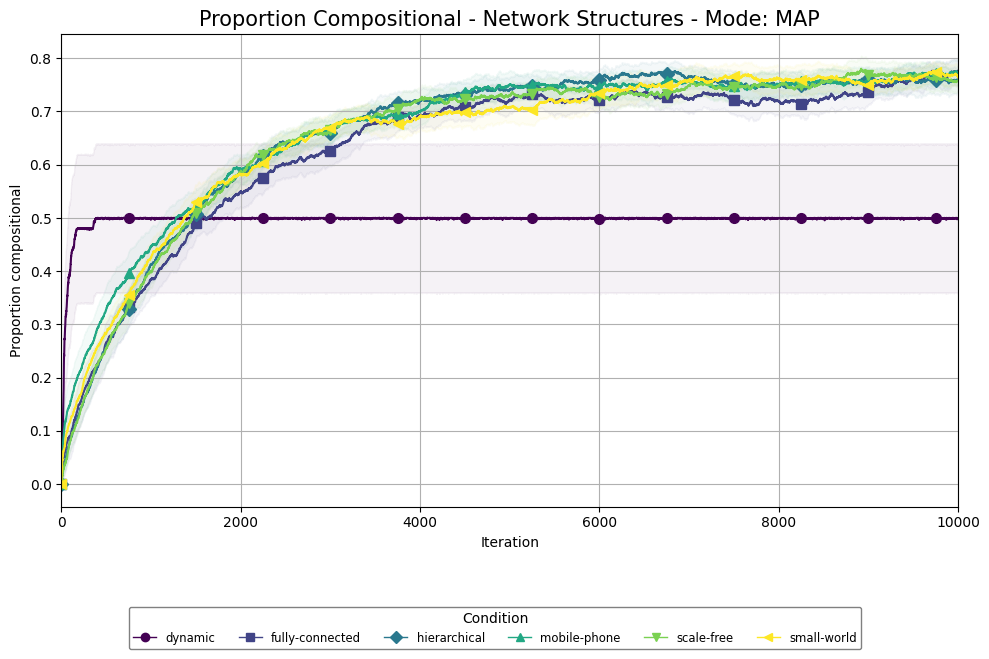

  dynamic: 0.580 (95% CI: 0.442 – 0.718)
  fully-connected: 0.769 (95% CI: 0.744 – 0.794)
  hierarchical: 0.745 (95% CI: 0.722 – 0.768)
  mobile-phone: 0.759 (95% CI: 0.736 – 0.782)
  scale-free: 0.745 (95% CI: 0.719 – 0.770)
  small-world: 0.751 (95% CI: 0.723 – 0.779)


<Figure size 640x480 with 0 Axes>

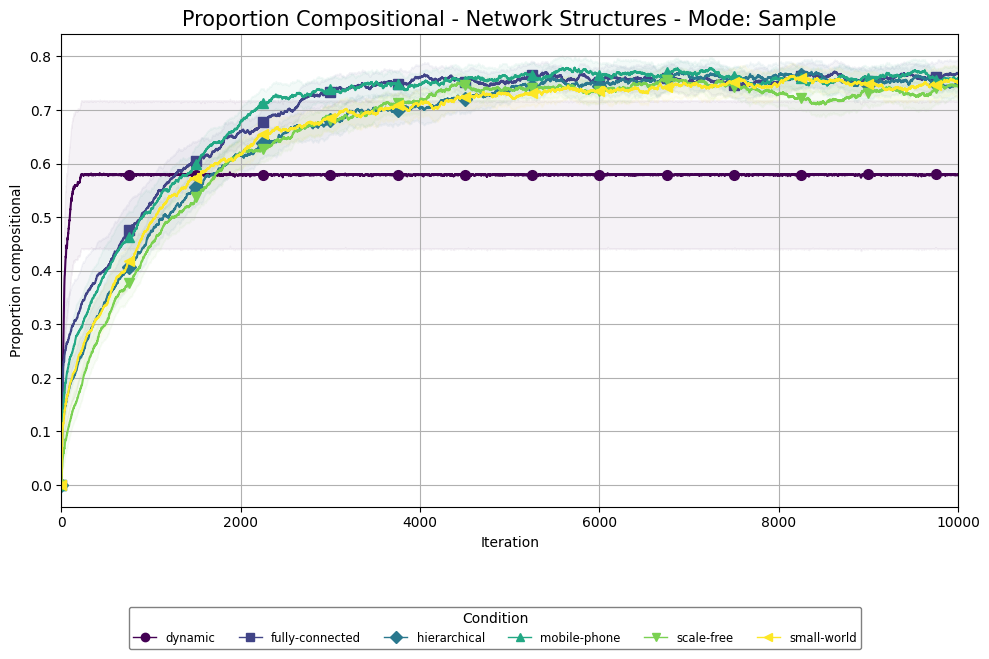

<Figure size 640x480 with 0 Axes>

In [19]:
for mode in modes:
    path = f"Networks/plots/baseline/{mode}/{mode}"

    fast_plot_ex3(path, f"Proportion Compositional - Network Structures - Mode: {mode}", f"Networks/plots/baseline/{mode}/{mode}")


In [20]:
def plot_grid_network(big_df, save_to, mode, replace):
    network_types = ["fully-connected", "small-world", "scale-free", "dynamic", "hierarchical", "mobile-phone"]  

    # Create a 2x3 grid of subplots
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))  
    axes = axes.flatten()  # flatten to iterate easily

    for j, r in enumerate(network_types):
        ax = axes[j]
        subset = big_df[big_df["condition"] == r]

        if not subset.empty:
            plot_each_language_type_ax(ax, subset, f"Network Type = {r}")
        else:
            ax.axis("off")

        # Axis labels
        ax.set_xlabel("Iteration", fontsize=9)
        if j % 3 == 0:  # first column
            ax.set_ylabel("Avg. Proportion", fontsize=9)
        
        # Limit x-axis to 0-10000
        ax.set_xlim(0, 10000)


    # Turn off any unused axes if population_sizes < total axes
    for k in range(len(network_types), len(axes)):
        axes[k].axis("off")

    # Legend: gather from first axis
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=4,
        bbox_to_anchor=(0.5, -0.02),
        title="Type",
        fontsize=9,
        frameon=True
    )

    # Title
    replace_str = "1 Agent per Iteration"
    fig.suptitle(f" Proportion per language type - Mode: {mode}, Replacement: {replace_str}", fontsize=14, y=0.95)

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.9])
    plt.savefig(f"{save_to}_types.pdf", bbox_inches="tight", pad_inches=0.05)
    plt.show()


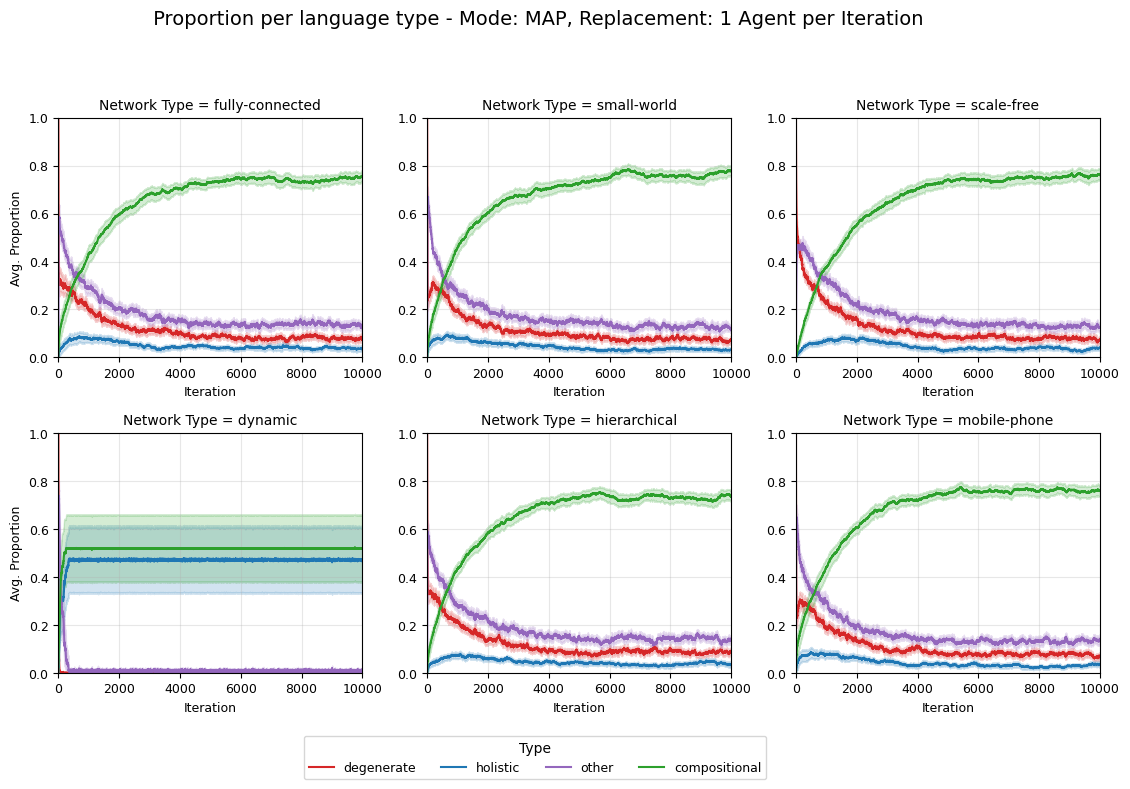

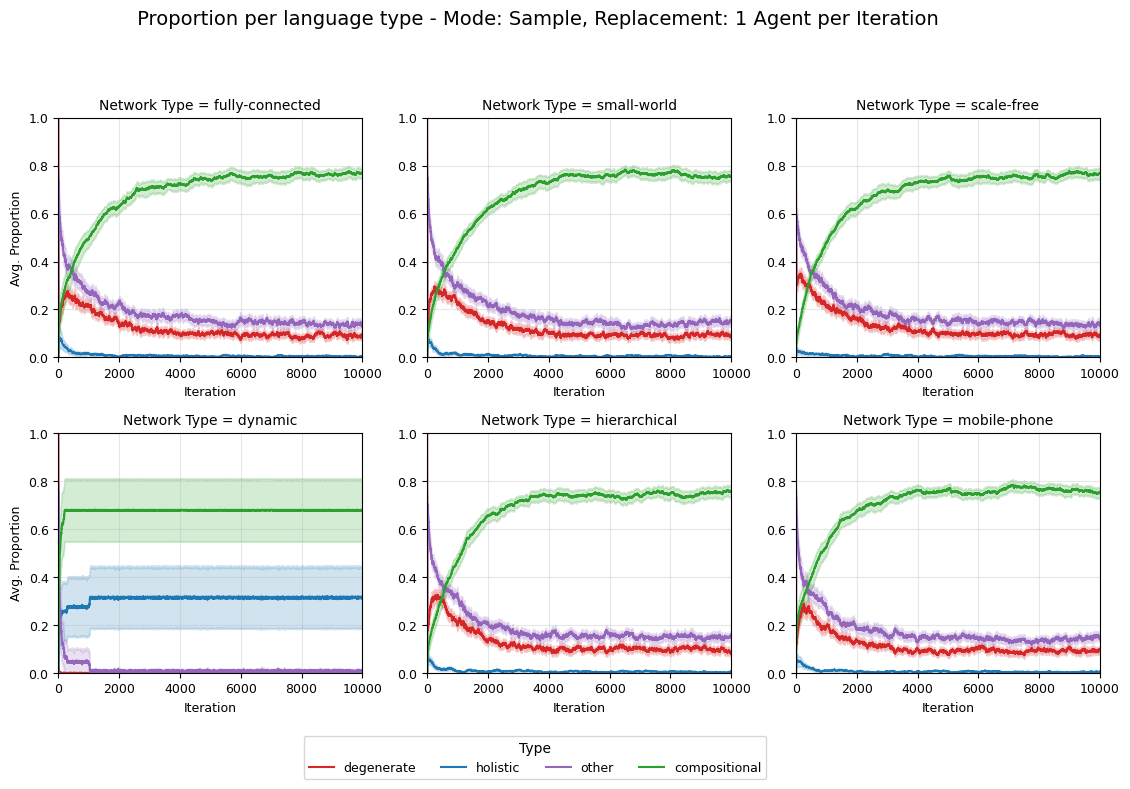

In [21]:
for mode in modes:
    path = f"Networks/plots/comsuc/{mode}/{mode}"
    df = pd.read_csv(f"{path}.csv")

    plot_grid_network(df, path, mode, False)


In [23]:

for mode in modes:
    df_list = []
    for network in networks:
        for run in range(n_runs):
            path = f"Networks/results_snellius2/{mode}/{network}/network_data/run{run}.csv"
            df = pd.read_csv(path)
            df['type'] = network
            df_list.append(df)

    save_dir = f"Networks/plots/network_data/{mode}"
    os.makedirs(save_dir, exist_ok=True)

    big_df = pd.concat(df_list)

    # Compute mean and std
    grouped = big_df.groupby('type')
    means = grouped.mean()
    stds = grouped.std()

    # Rename columns for clarity
    means.columns = [f"{col}_mean" for col in means.columns]
    stds.columns = [f"{col}_std" for col in stds.columns]

    # Combine into one DataFrame
    result = pd.concat([means, stds], axis=1)

    # Save to CSV
    result.to_csv(f"{save_dir}/means.csv")

    

In [24]:
# Combine mean and std into "mean ± std" formatted strings
nice_table = pd.DataFrame(index=means.index)

for col in grouped.mean().columns:
    if col != "Unnamed: 0":
        nice_table[col] = means[f"{col}_mean"].round(3).astype(str) + " ± " + stds[f"{col}_std"].round(3).astype(str)

print(nice_table)
nice_table.to_csv(f"{save_dir}/nice_table.csv")


                average_degree clustering_coef average_shortest_path  \
type                                                                   
dynamic          3.279 ± 0.418   0.158 ± 0.072          2.61 ± 0.249   
fully-connected     24.0 ± 0.0       1.0 ± 0.0             1.0 ± 0.0   
hierarchical        5.28 ± 0.0     0.902 ± 0.0           2.033 ± 0.0   
mobile-phone     8.827 ± 0.038   0.261 ± 0.006         1.643 ± 0.006   
scale-free        2.624 ± 0.28   0.178 ± 0.061         2.382 ± 0.146   
small-world          4.0 ± 0.0   0.383 ± 0.058          2.81 ± 0.183   

                        n_edges         n_nodes  
type                                             
dynamic          38.713 ± 5.626  23.587 ± 1.202  
fully-connected     300.0 ± 0.0      25.0 ± 0.0  
hierarchical         66.0 ± 0.0      25.0 ± 0.0  
mobile-phone     110.34 ± 0.474      25.0 ± 0.0  
scale-free         32.8 ± 3.504      25.0 ± 0.0  
small-world          50.0 ± 0.0      25.0 ± 0.0  


### Replace

In [26]:
modes = ["Sample", "MAP"]
probs = [0.0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.90, 1.0]
n_runs = 50

for mode in modes:
    list_df = []
    missing_runs = []

    for prob in probs:
        for run in range(n_runs):
            filepath = f"Replacement/results_snellius/{mode}/{prob}/run{run}.csv"

            if not os.path.exists(filepath):
                print(f"Missing file: {filepath}")
                missing_runs.append(filepath)
                continue  # skip if missing

            try:
                df = pd.read_csv(filepath)
                df["condition"] = prob
                df["run"] = run
                df["mode"] = mode
                list_df.append(df)
            except Exception as e:
                print(f"Error reading {filepath}: {e}")
                missing_runs.append(filepath)
                continue

    save_dir = f"Replacement/plots/{mode}"
    os.makedirs(save_dir, exist_ok=True)

    if list_df:
        big_df = pd.concat(list_df, ignore_index=True)

        big_df.to_csv(f"{save_dir}/{mode}.csv", index=False)
        print(f"Saved {save_dir}/{mode}.csv ({len(big_df)} rows)")
    else:
        print(f"No valid data found for mode={mode}")

    # Write missing runs to text file
    if missing_runs:
        missing_path = f"{save_dir}/missing_runs.txt"
        with open(missing_path, "w") as f:
            for filepath in missing_runs:
                f.write(filepath + "\n")
        print(f"Missing runs logged in {missing_path}")

Saved Replacement/plots/Sample/Sample.csv (4500450 rows)
Saved Replacement/plots/MAP/MAP.csv (4500450 rows)


In [27]:
def fast_plot_replace(csv_path1, title, save_path):
    # Load CSV
    df1 = pd.read_csv(f"{csv_path1}.csv")

    # Helper function to compute CI summary
    def compute_summary(df):
        grouped = df.groupby(['condition', 'generation'])['compositional']
        mean = grouped.mean()
        sem = grouped.sem()
        ci_hi = mean + 1.96 * sem
        ci_lo = mean - 1.96 * sem
        return pd.DataFrame({'mean': mean, 'ci_lo': ci_lo, 'ci_hi': ci_hi}).reset_index()

    summary1 = compute_summary(df1)

    # Sort conditions
    conditions = sorted(summary1['condition'].unique())

    # Use Set3 colormap
    colors = plt.cm.tab20(np.linspace(0, 1, len(conditions)))
    condition_to_color = dict(zip(conditions, colors))

    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'x', '+']
    marker_cycle = {cond: markers[i % len(markers)] for i, cond in enumerate(conditions)}

    # Set up the figure and axis
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot each condition
    for condition in conditions:
        cond_data = summary1[summary1['condition'] == condition]
        ax.plot(
            cond_data['generation'], cond_data['mean'],
            color=condition_to_color[condition],
            marker=marker_cycle[condition],
            label=condition,
            markersize=7.5, linewidth=1, markevery=750
        )
        ax.fill_between(
            cond_data['generation'],
            cond_data['ci_lo'], cond_data['ci_hi'],
            color=condition_to_color[condition],
            alpha=0.05,
            rasterized=True
        )


    # Axis labels and grid
    ax.set_title(title, fontsize=20)
    ax.set_xlabel('Iterations', fontsize=18)
    ax.set_ylabel('Proportion compositional', fontsize=20)
    ax.grid(True)
    ax.set_xlim(-1, summary1['generation'].max())

    # Legend below the plot
    ax.legend(
        title='Condition',
        loc='lower center',
        ncol=3, fontsize=16, title_fontsize=18,
        frameon=True, framealpha=1.0, edgecolor='grey',
        bbox_to_anchor=(0.5, -0.5)
    )

    # Tight layout with space for legend
    #fig.tight_layout(rect=[0, 0.0, 1, 0.95])
    fig.subplots_adjust(bottom=0.2)
    plt.savefig(f"{save_path}.pdf", bbox_inches='tight', pad_inches=0.05)
    plt.show()
    plt.clf()


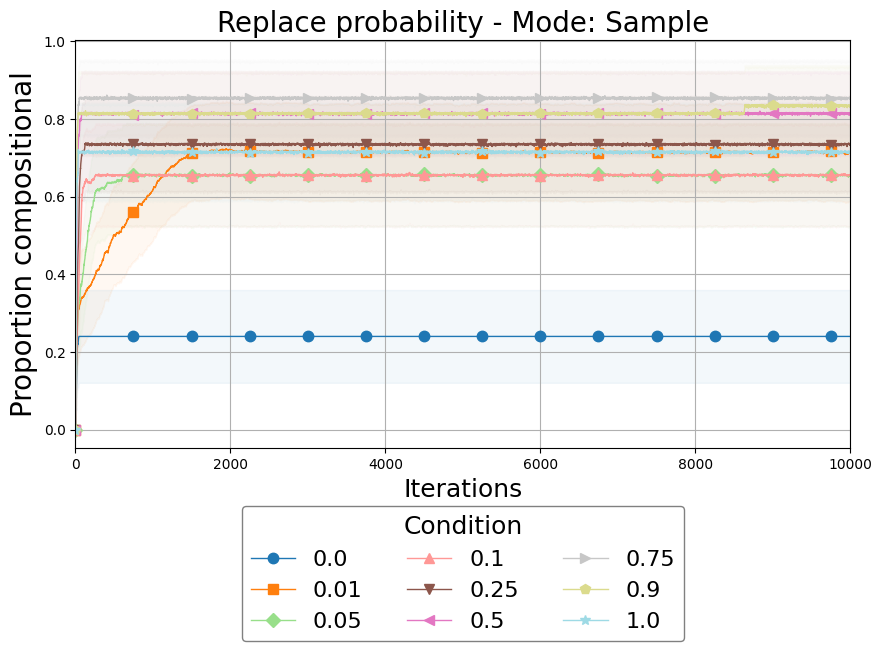

<Figure size 640x480 with 0 Axes>

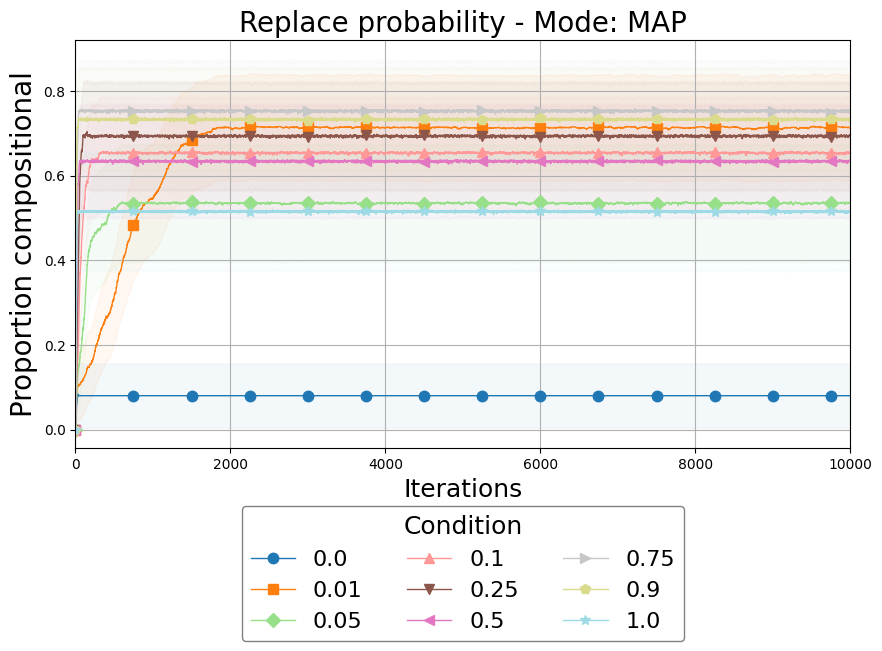

<Figure size 640x480 with 0 Axes>

In [28]:
for mode in modes:
    path = f"Replacement/plots/{mode}/{mode}"

    fast_plot_replace(path, f"Replace probability - Mode: {mode}", f"Replacement/plots/{mode}/{mode}")
